# Customer Segmentation with KMeans Clustering

## Real-World Customer Segmentation using Python

In this project, we will:

- Create and inspect customer data
- Select useful features
- Scale numerical features
- Find a suitable number of clusters using the Elbow Method
- Train a KMeans Clustering model
- Assign customers to clusters
- Analyze cluster profiles
- Calculate Silhouette Score
- Visualize customer segments
- Export the final segmented dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

## 1. Create Customer Dataset

For this notebook, we create a reproducible customer dataset.

The dataset contains:

- Customer ID
- Age
- Annual Income
- Spending Score
- Number of Purchases

The same workflow can later be applied to a real customer CSV dataset.

In [2]:
# Reproducible random generator
rng = np.random.default_rng(42)

# Number of customers
n = 300

# Create customer dataset
df = pd.DataFrame({
    "Customer_ID": np.arange(1, n + 1),
    "Age": rng.integers(18, 61, n),
    "Annual_Income": rng.integers(15000, 120001, n),
    "Spending_Score": rng.integers(1, 101, n),
    "Purchases": rng.integers(1, 31, n)
})

df.head()

,Customer_ID,Age,Annual_Income,Spending_Score,Purchases
0,1,21,53186,62,1
1,2,51,101761,78,2
2,3,46,16041,74,7
3,4,36,109097,14,27
4,5,36,71997,83,14


In [3]:
# Check dataset shape
print("Dataset Shape:", df.shape)

# Display information
df.info()

Dataset Shape: (300, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Customer_ID     300 non-null    int64
 1   Age             300 non-null    int64
 2   Annual_Income   300 non-null    int64
 3   Spending_Score  300 non-null    int64
 4   Purchases       300 non-null    int64
dtypes: int64(5)
memory usage: 11.8 KB


In [4]:
# Statistical summary
df.describe()

,Customer_ID,Age,Annual_Income,Spending_Score,Purchases
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,38.936667,67682.970000,51.890000,15.593333
std,86.746758,11.717379,32188.679495,29.670282,8.233301
min,1.000000,18.000000,15557.000000,1.000000,1.000000
25%,75.750000,29.000000,39363.250000,24.750000,9.000000
50%,150.500000,39.000000,67776.500000,54.000000,16.000000
75%,225.250000,49.000000,98767.750000,78.000000,22.000000
max,300.000000,60.000000,119793.000000,100.000000,30.000000


In [5]:
# Check missing values
df.isnull().sum()

Customer_ID       0
Age               0
Annual_Income     0
Spending_Score    0
Purchases         0
dtype: int64

In [6]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## 2. Select Features

KMeans works with numerical features.

For customer segmentation, we will use:

- Annual Income
- Spending Score
- Purchases

Customer_ID is not used because it is only an identifier.

In [7]:
features = [
    "Annual_Income",
    "Spending_Score",
    "Purchases"
]

X = df[features].copy()

X.head()

,Annual_Income,Spending_Score,Purchases
0,53186,62,1
1,101761,78,2
2,16041,74,7
3,109097,14,27
4,71997,83,14


## 3. Feature Scaling

KMeans is a distance-based algorithm.

Since the selected features have different numerical ranges, we scale them using StandardScaler.

In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.4511273 ,  0.34131432, -1.77543812],
       [ 1.06046503,  0.88147546, -1.65377721],
       [-1.60703255,  0.74643518, -1.0454727 ],
       [ 1.28875204, -1.2791691 ,  1.38774537],
       [ 0.13424714,  1.05027582, -0.19384637]])

In [9]:
# Convert scaled data back to DataFrame for easy inspection

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features
)

X_scaled_df.head()

,Annual_Income,Spending_Score,Purchases
0,-0.451127,0.341314,-1.775438
1,1.060465,0.881475,-1.653777
2,-1.607033,0.746435,-1.045473
3,1.288752,-1.279169,1.387745
4,0.134247,1.050276,-0.193846


## 4. Find the Number of Clusters using the Elbow Method

We calculate KMeans inertia for different values of K.

The point where the improvement in inertia starts decreasing significantly can be considered a candidate for the number of clusters.

In [10]:
inertias = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X_scaled)
    
    inertias.append(model.inertia_)

inertias

[663.2463427465991,
 505.8994328447558,
 399.89864081102917,
 339.98349315380403,
 277.80070189269634,
 245.1398263380446,
 214.97928951414409,
 200.14024804475912,
 182.45736343263542]

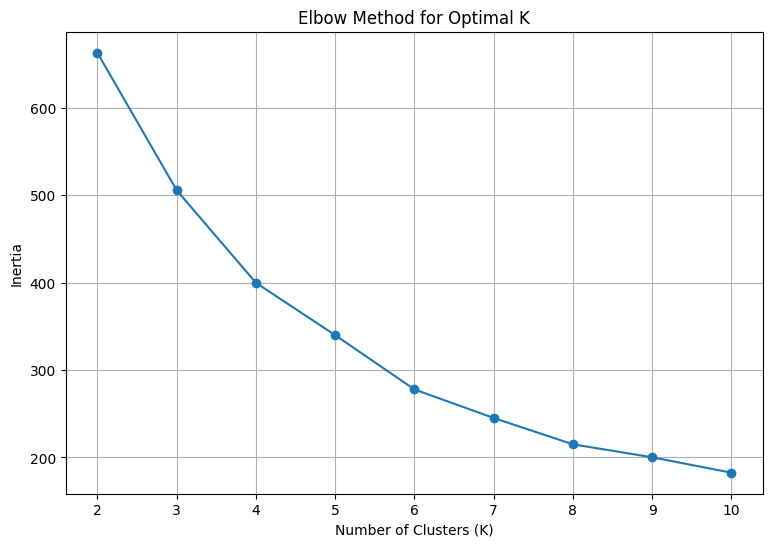

In [11]:
plt.figure(figsize=(9, 6))

plt.plot(
    range(2, 11),
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.xticks(range(2, 11))

plt.grid()
plt.show()

## 5. Train the KMeans Model

Based on the Elbow Method, we select a suitable value of K.

For this example, we use:

K = 5

In [12]:
K = 5

kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,Customer_ID,Age,Annual_Income,Spending_Score,Purchases,Cluster
0,1,21,53186,62,1,3
1,2,51,101761,78,2,0
2,3,46,16041,74,7,3
3,4,36,109097,14,27,2
4,5,36,71997,83,14,0


In [13]:
# Check number of customers in each cluster

cluster_counts = df["Cluster"].value_counts().sort_index()

cluster_counts

Cluster
0    50
1    59
2    53
3    75
4    63
Name: count, dtype: int64

In [14]:
# Display cluster distribution as percentages

cluster_percentage = (
    df["Cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

cluster_percentage

Cluster
0    16.67
1    19.67
2    17.67
3    25.00
4    21.00
Name: proportion, dtype: float64

## 6. Cluster Profiling

Cluster numbers themselves do not have business meaning.

We analyze the average values of the selected features for every cluster.

In [15]:
cluster_profile = (
    df.groupby("Cluster")[features]
    .mean()
    .round(2)
)

cluster_profile

,Annual_Income,Spending_Score,Purchases
Cluster,,,
0,97556.48,75.04,9.38
1,49397.31,19.58,21.69
2,97366.75,20.89,11.21
3,36008.45,67.20,10.81
4,73834.19,71.63,24.19


In [16]:
# Include number of customers in each cluster

cluster_profile_with_count = (
    df.groupby("Cluster")[features]
    .mean()
    .round(2)
)

cluster_profile_with_count["Customer_Count"] = (
    df["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_profile_with_count

,Annual_Income,Spending_Score,Purchases,Customer_Count
Cluster,,,,
0,97556.48,75.04,9.38,50
1,49397.31,19.58,21.69,59
2,97366.75,20.89,11.21,53
3,36008.45,67.20,10.81,75
4,73834.19,71.63,24.19,63


## 7. Analyze Cluster Characteristics

We can inspect the cluster profile to understand the behavior represented by each group.

For example, depending on the actual data, a cluster may contain customers with:

- Higher income
- Higher spending
- More purchases
- Lower spending
- Fewer purchases

The cluster labels are identifiers, so their meaning should be determined from the actual statistics.

In [17]:
# Sort clusters by average spending score

cluster_profile.sort_values(
    by="Spending_Score",
    ascending=False
)

,Annual_Income,Spending_Score,Purchases
Cluster,,,
0,97556.48,75.04,9.38
4,73834.19,71.63,24.19
3,36008.45,67.20,10.81
2,97366.75,20.89,11.21
1,49397.31,19.58,21.69


## 8. Silhouette Score

The Silhouette Score provides a measure of how well-separated the clusters are.

A higher score generally indicates better separation under this metric.

However, it should be interpreted together with the cluster profiles and business context.

In [18]:
silhouette = silhouette_score(
    X_scaled,
    df["Cluster"]
)

print("Silhouette Score:", round(silhouette, 4))

Silhouette Score: 0.29


## 9. Visualize Customer Segments

We will visualize:

- Annual Income
- Spending Score

Different cluster labels will be displayed separately.

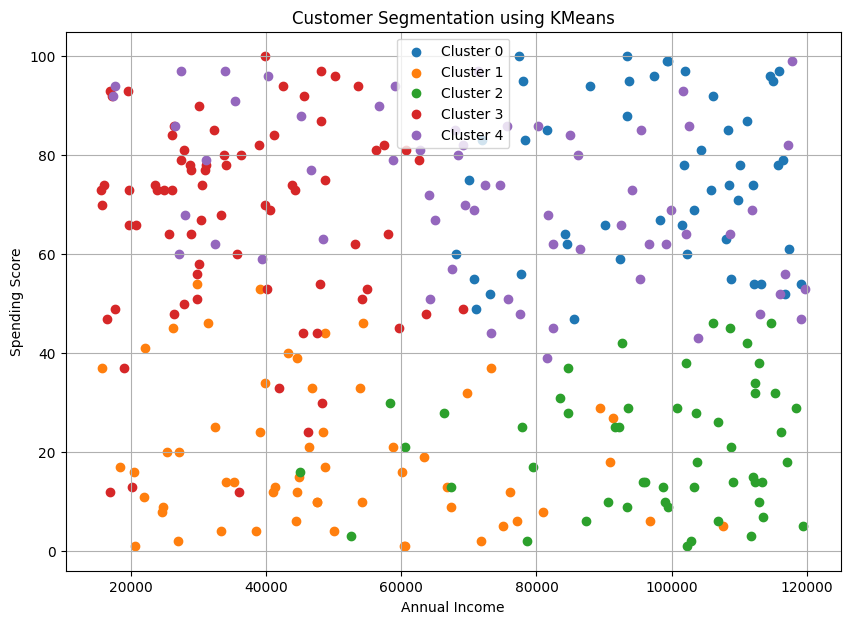

In [19]:
plt.figure(figsize=(10, 7))

for cluster in sorted(df["Cluster"].unique()):
    
    cluster_data = df[
        df["Cluster"] == cluster
    ]
    
    plt.scatter(
        cluster_data["Annual_Income"],
        cluster_data["Spending_Score"],
        label=f"Cluster {cluster}"
    )

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using KMeans")
plt.legend()
plt.grid()

plt.show()

## 10. Visualize Cluster Distribution

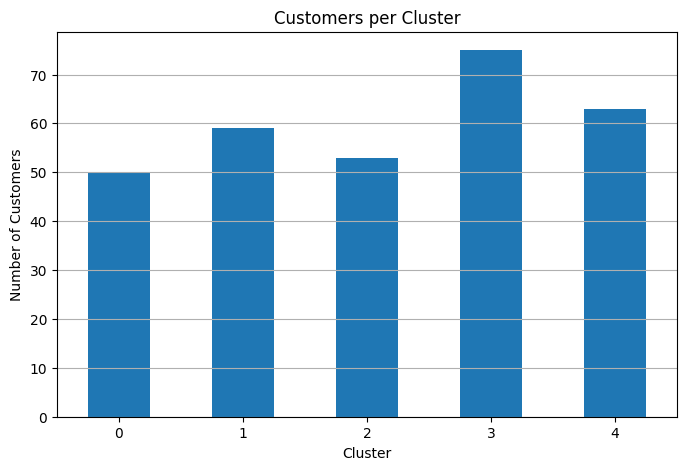

In [20]:
plt.figure(figsize=(8, 5))

cluster_counts.plot(
    kind="bar"
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Customers per Cluster")

plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

## 11. Analyze Cluster Centroids

KMeans creates a centroid for every cluster.

The centroids are stored in the model and are currently represented in scaled feature space.

In [21]:
centroids_scaled = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=features
)

centroids_scaled

,Annual_Income,Spending_Score,Purchases
0,0.929626,0.781546,-0.755920
1,-0.569027,-1.090914,0.742324
2,0.923722,-1.046670,-0.533579
3,-0.985671,0.516867,-0.581539
4,0.191418,0.666590,1.045936


In [22]:
# Convert centroids back to the original feature scale

centroids_original = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
)

centroids_original.round(2)

,Annual_Income,Spending_Score,Purchases
0,97556.48,75.04,9.38
1,49397.31,19.58,21.69
2,97366.75,20.89,11.21
3,36008.45,67.20,10.81
4,73834.19,71.63,24.19


## 12. Final Segmented Dataset

The `Cluster` column contains the segment assigned to every customer.

In [23]:
# Display complete final dataset

df

,Customer_ID,Age,Annual_Income,Spending_Score,Purchases,Cluster
0,1,21,53186,62,1,3
1,2,51,101761,78,2,0
2,3,46,16041,74,7,3
3,4,36,109097,14,27,2
4,5,36,71997,83,14,0
...,...,...,...,...,...,...
295,296,40,99213,62,20,4
296,297,54,75833,51,22,4
297,298,36,96845,6,30,1
298,299,30,80921,8,25,1


## 13. Export Customer Segmentation Results

We save the final dataset as a CSV file.

The exported file contains the original customer information along with the generated cluster label.

In [24]:
output_file = "customer_segments.csv"

df.to_csv(
    output_file,
    index=False
)

print(f"File saved successfully: {output_file}")

File saved successfully: customer_segments.csv


In [25]:
# Verify exported file

pd.read_csv(output_file).head()

,Customer_ID,Age,Annual_Income,Spending_Score,Purchases,Cluster
0,1,21,53186,62,1,3
1,2,51,101761,78,2,0
2,3,46,16041,74,7,3
3,4,36,109097,14,27,2
4,5,36,71997,83,14,0


# Conclusion

In this project, we built a complete customer segmentation workflow using KMeans Clustering.

### We performed:

1. Customer dataset creation
2. Data inspection
3. Missing-value checking
4. Duplicate checking
5. Feature selection
6. Feature scaling
7. Elbow Method analysis
8. KMeans model training
9. Cluster assignment
10. Cluster profiling
11. Silhouette Score calculation
12. Customer segment visualization
13. Cluster distribution analysis
14. Centroid analysis
15. Exporting the segmented dataset

The resulting customer segments can be further analyzed and used as the foundation for an interactive Streamlit customer segmentation application.